# 1 Data Loading

In [47]:
#pip install pandas scikit-learn keras tensorflow matplotlib seaborn numpy

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [49]:
import pandas as pd

# 1. Load the 'train.csv' file into a DataFrame
try:
    df_train = pd.read_csv('train.csv')
    print("Training data loaded successfully.")
    print("\n--- Preview of the training data ---")
    print(df_train.head())
    print("\n--- General info on the training data ---")
    df_train.info()

except FileNotFoundError:
    print("Error: The 'train.csv' file was not found. Make sure it's in the same directory as your script.")
    df_train = None  # Set to None to avoid errors if the file doesn't load

print("\n" + "="*50 + "\n")  # Separator for better readability

# 2. Load the 'test.csv' file into a DataFrame
try:
    df_test = pd.read_csv('test.csv')
    print("Test data loaded successfully.")
    print("\n--- Preview of the test data ---")
    print(df_test.head())
    print("\n--- General info on the test data ---")
    df_test.info()

except FileNotFoundError:
    print("Error: The 'test.csv' file was not found. Make sure it's in the same directory as your script.")
    df_test = None  # Set to None to avoid errors if the file doesn't load

# If both DataFrames were loaded correctly, you can check their dimensions
if df_train is not None and df_test is not None:
    print("\n--- Dimensions of the DataFrames ---")
    print(f"Training DataFrame: {df_train.shape}")
    print(f"Test DataFrame: {df_test.shape}")

Training data loaded successfully.

--- Preview of the training data ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000

Generating visualizations...

--- Missing Values Table ---
          Missing Values  % Missing
Cabin                687      77.10
Age                  177      19.87
Embarked               2       0.22




C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\340107128.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_train, palette='coolwarm')
C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\340107128.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df_train, palette='viridis')


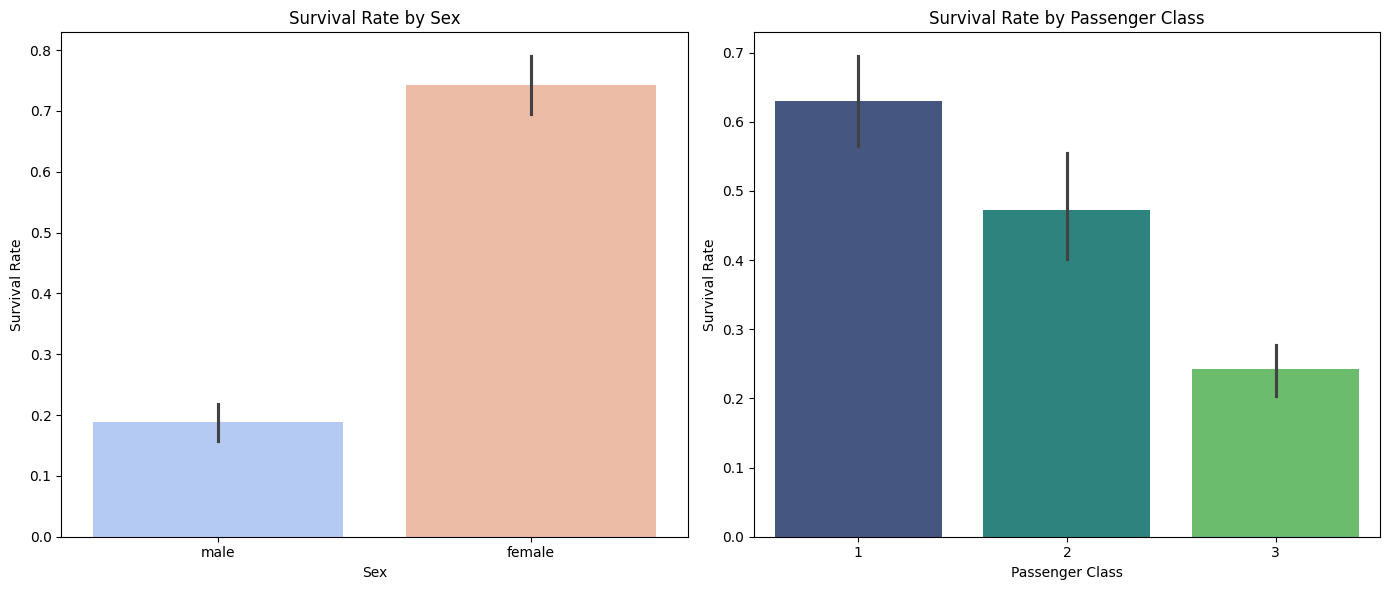

C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\340107128.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Title', data=df_train, palette='crest')
C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\340107128.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Title', y='Survived', data=df_train, palette='magma')


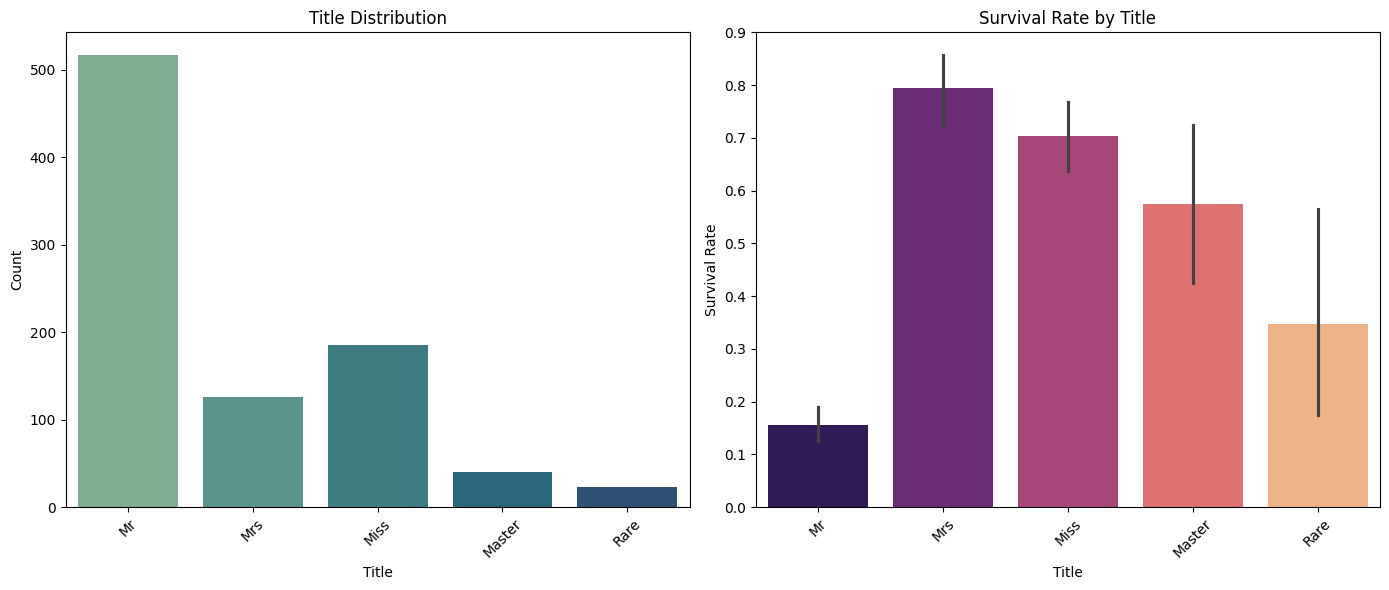



All visualizations generated.


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Assuming df_train is already loaded from previous steps ---
# If not, load it:
try:
    df_train = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Error: 'train.csv' not found. Please ensure it's in the same directory.")
    exit()

print("Generating visualizations...")

# --- 1. Missing Values Analysis (Now with a Table instead of a Heatmap) ---
print("\n--- Missing Values Table ---")
# Calculate missing data for all columns
missing_data = df_train.isnull().sum()
# Filter to show only columns with missing values
missing_data = missing_data[missing_data > 0]
# Calculate the percentage of missing values
missing_percent = (missing_data / len(df_train)) * 100
# Create a DataFrame for a clean table-like output
missing_info_df = pd.DataFrame({
    'Missing Values': missing_data,
    '% Missing': missing_percent.round(2)
}).sort_values(by='% Missing', ascending=False)
print(missing_info_df)

print("\n") # Just for spacing in console

# --- 2. Key Demographics & Survival Rates ---
plt.figure(figsize=(14, 6))

# Subplot 1: Survival Rate by Sex
plt.subplot(1, 2, 1)
sns.barplot(x='Sex', y='Survived', data=df_train, palette='coolwarm')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.xlabel('Sex')

# Subplot 2: Survival Rate by Passenger Class
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df_train, palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')

plt.tight_layout()
plt.show()
print("\n")

# --- 3. Feature Engineering Impact (Title Extraction) ---
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

df_train['Title'] = df_train['Name'].apply(get_title)
df_train['Title'] = df_train['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_train['Title'] = df_train['Title'].replace('Mlle', 'Miss')
df_train['Title'] = df_train['Title'].replace('Ms', 'Miss')
df_train['Title'] = df_train['Title'].replace('Mme', 'Mrs')

plt.figure(figsize=(14, 6))

# Subplot 1: Title Distribution
plt.subplot(1, 2, 1)
sns.countplot(x='Title', data=df_train, palette='crest')
plt.title('Title Distribution')
plt.ylabel('Count')
plt.xlabel('Title')
plt.xticks(rotation=45)

# Subplot 2: Survival Rate by Title
plt.subplot(1, 2, 2)
sns.barplot(x='Title', y='Survived', data=df_train, palette='magma')
plt.title('Survival Rate by Title')
plt.ylabel('Survival Rate')
plt.xlabel('Title')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("\n")

print("All visualizations generated.")

# 2 Feature Engineering Cleaning Data

### 2.1 Extract the 'Title' from the 'Name' column

In [51]:
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

df_train['Title'] = df_train['Name'].apply(get_title)
df_test['Title'] = df_test['Name'].apply(get_title)

# Consolidate rare titles and map them to common ones
df_train['Title'] = df_train['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_train['Title'] = df_train['Title'].replace('Mlle', 'Miss')
df_train['Title'] = df_train['Title'].replace('Ms', 'Miss')
df_train['Title'] = df_train['Title'].replace('Mme', 'Mrs')

df_test['Title'] = df_test['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_test['Title'] = df_test['Title'].replace('Mlle', 'Miss')
df_test['Title'] = df_test['Title'].replace('Ms', 'Miss')
df_test['Title'] = df_test['Title'].replace('Mme', 'Mrs')
# Note: Dr is sometimes considered Rare in test data; we handle it with the Rare mapping.


### 2.2 Selecting key features

In [52]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']
target = 'Survived'

X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]

### 2.3 Handle Missing Values

In [53]:
# Fill 'Age' with the median of the column
X_train['Age'].fillna(X_train['Age'].median(), inplace=True)
X_test['Age'].fillna(X_test['Age'].median(), inplace=True)

# Fill 'Fare' with the median (only the test set has a missing value here)
X_test['Fare'].fillna(X_test['Fare'].median(), inplace=True)

# Fill 'Embarked' with the mode (the most frequent value)
X_train['Embarked'].fillna(X_train['Embarked'].mode()[0], inplace=True)
X_test['Embarked'].fillna(X_test['Embarked'].mode()[0], inplace=True)

C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\363038872.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Age'].fillna(X_train['Age'].median(), inplace=True)
C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\363038872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Age'].fillna(X_train['Age'].median(), inplace=True)

### 2.4 Convert Categorical Variables to Numerical

In [54]:
# Convert 'Sex' (male/female) to 0/1
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

# Apply One-Hot Encoding to 'Embarked'
# We'll use get_dummies on the entire DataFrame to ensure both train and test sets have the same columns
combined_df = pd.concat([X_train, X_test], ignore_index=True, sort=False)
combined_df = pd.get_dummies(combined_df, columns=['Sex'], drop_first=True)
combined_df = pd.get_dummies(combined_df, columns=['Embarked'], drop_first=True)
combined_df = pd.get_dummies(combined_df, columns=['Title'], drop_first=True)

# Split back into training and test sets
X_train_processed = combined_df.iloc[:len(X_train)]
X_test_processed = combined_df.iloc[len(X_train):]

C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\4147509012.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
C:\Users\hugoa\AppData\Local\Temp\ipykernel_16880\4147509012.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})


# 3 Training the Model

### 3.1 Initialize and Train the Model

In [59]:
# Initialize the classifier
# n_estimators: number of trees in the forest
# random_state: to ensure reproducible results
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2a. Train the final model on the full training set for submission
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_processed, y_train)

# 2b. Split the processed training data for internal validation
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train_processed, y_train, test_size=0.2, random_state=42)

# 2c. Train a separate model for validation purposes
model_val = RandomForestClassifier(n_estimators=100, random_state=42)
model_val.fit(X_train_split, y_train_split)

# 2d. Make predictions on the validation set and evaluate accuracy
predictions = model_val.predict(X_val)
accuracy = accuracy_score(y_val, predictions)
print(f"The model's accuracy on the validation set is: {accuracy:.2f}")

The model's accuracy on the validation set is: 0.83


### 4 Model Prediction and Evaluation

In [ ]:
# Make predictions on the complete processed test set
test_predictions = model.predict(X_test_processed)

# Create the submission DataFrame with the correct format
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": test_predictions
})

# Save the results to a CSV file
submission.to_csv('submission.csv', index=False)
print("\n'submission.csv' file created successfully.")


'submission.csv' file created successfully.
